In [1]:
import json
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
INCLUDE_NEG_SAMPLES = True

In [3]:
# easy_logs = json.load(open("../data/logs/easy_link_prediction_logs.json"))
# medium_logs = json.load(open("../data/logs/medium_link_prediction_logs.json"))
# hard_logs = json.load(open("../data/logs/hard_link_prediction_logs.json"))

easy_logs = json.load(open("../data/logs/directed_mad3.5/easy_link_prediction_logs.json"))
medium_logs = json.load(open("../data/logs/directed_mad3.5/medium_link_prediction_logs.json"))
hard_logs = json.load(open("../data/logs/directed_mad3.5/hard_link_prediction_logs.json"))
most_recent_logs = json.load(open("../data/logs/directed_mad3.5/most_recent_link_prediction_logs.json"))

In [4]:
# easy_info = json.load(open("../data/processed/easy_edges.json"))
# medium_info = json.load(open("../data/processed/medium_edges.json"))
# hard_info = json.load(open("../data/processed/hard_edges.json"))

easy_info = json.load(open("../data/labels/directed_mad3.5/easy_edges.json"))
medium_info = json.load(open("../data/labels/directed_mad3.5/medium_edges.json"))
hard_info = json.load(open("../data/labels/directed_mad3.5/hard_edges.json"))
most_recent_info = json.load(open("../data/labels/directed_mad3.5/most_recent_edges.json"))

In [5]:
if INCLUDE_NEG_SAMPLES:
    easy_labels = [pred['true_label'] for pred in easy_logs]
    medium_labels = [pred['true_label'] for pred in medium_logs]
    hard_labels = [pred['true_label'] for pred in hard_logs]
    most_recent_labels = [pred['true_label'] for pred in most_recent_logs]

    easy_preds = [pred['pred_label'] for pred in easy_logs]
    medium_preds = [pred['pred_label'] for pred in medium_logs]
    hard_preds = [pred['pred_label'] for pred in hard_logs]
    most_recent_preds = [pred['pred_label'] for pred in most_recent_logs]

else:
    easy_labels = [pred['true_label'] for pred in easy_logs if pred['true_label'] == 'positive']
    medium_labels = [pred['true_label'] for pred in medium_logs if pred['true_label'] == 'positive']
    hard_labels = [pred['true_label'] for pred in hard_logs if pred['true_label'] == 'positive']
    most_recent_labels = [pred['true_label'] for pred in most_recent_logs if pred['true_label'] == 'positive']

    easy_preds = [pred['pred_label'] for pred in easy_logs if pred['true_label'] == 'positive']
    medium_preds = [pred['pred_label'] for pred in medium_logs if pred['true_label'] == 'positive']
    hard_preds = [pred['pred_label'] for pred in hard_logs if pred['true_label'] == 'positive']
    most_recent_preds = [pred['pred_label'] for pred in most_recent_logs if pred['true_label'] == 'positive']


In [6]:
import numpy as np

In [7]:
(np.array(easy_labels) == 'positive').sum(), (np.array(medium_labels) == 'positive').sum(), (np.array(hard_labels) == 'positive').sum()

(np.int64(500), np.int64(500), np.int64(500))

# Visualizando matrizes de confusão

Considerando apenas o modelo **gemma3 de 4B parâmetros**.

- **Fáceis:** alto desempenho no geral (0.87 Macro-F1). Maior parte dos erros foram confundir negativos com positivos.
- **Médios:** queda no desempenho, dentro do esperado (0.72 Macro-F1). Diferente do anterior, a maior parte dos erros veio de confundir positivos com negativos.
- **Difíceis:** pior desemepenho (0.38 Macro-F1). Pior que o aleatório. Muitos positivos confundidos com negativos. 

Text(0.5, 1.0, 'Hard Link Prediction')

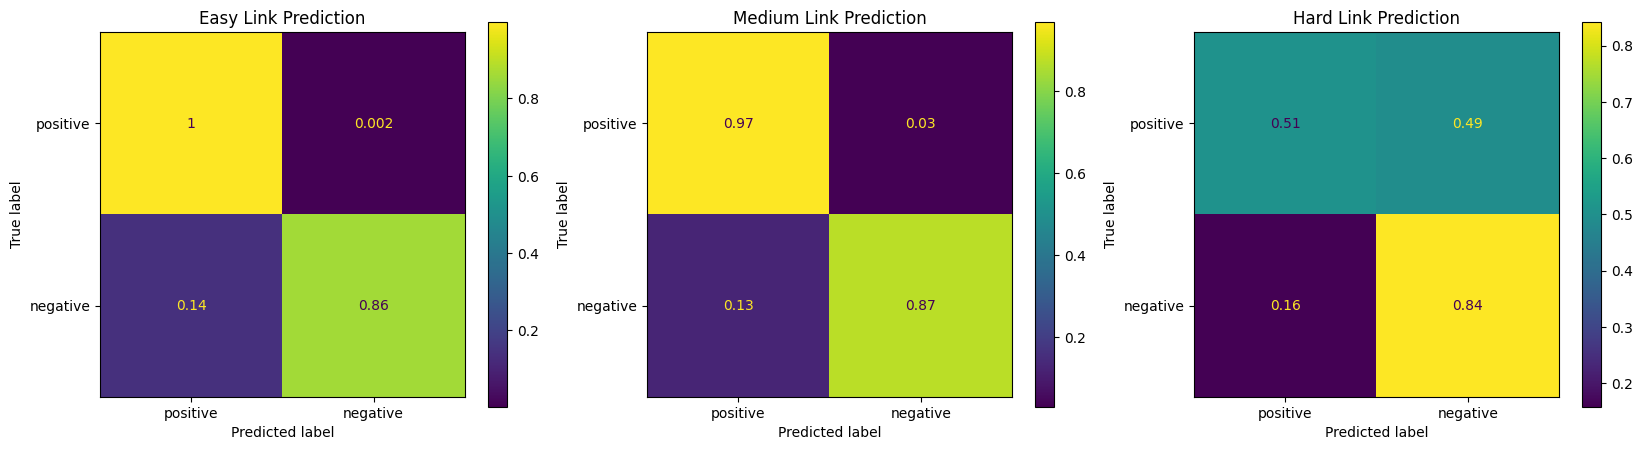

In [8]:
# visualizando matrizes de confusão
cm_easy = confusion_matrix(easy_labels, easy_preds, normalize='true', labels=['positive', 'negative'])
cm_medium = confusion_matrix(medium_labels, medium_preds, normalize='true', labels=['positive', 'negative'])
cm_hard = confusion_matrix(hard_labels, hard_preds, normalize='true', labels=['positive', 'negative'])

# mostrar porcentagens
disp_easy = ConfusionMatrixDisplay(confusion_matrix=cm_easy, display_labels=['positive', 'negative'])
disp_medium = ConfusionMatrixDisplay(confusion_matrix=cm_medium, display_labels=['positive', 'negative'])
disp_hard = ConfusionMatrixDisplay(confusion_matrix=cm_hard, display_labels=['positive', 'negative'])

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

disp_easy.plot(ax=axes[0])
axes[0].set_title("Easy Link Prediction")   

disp_medium.plot(ax=axes[1],)
axes[1].set_title("Medium Link Prediction")
    
disp_hard.plot(ax=axes[2])
axes[2].set_title("Hard Link Prediction")

In [9]:
# reports
print("Easy Link Prediction Report:")
print(classification_report(easy_preds, easy_labels))

Easy Link Prediction Report:
              precision    recall  f1-score   support

    negative       0.86      1.00      0.92       431
    positive       1.00      0.88      0.93       569

    accuracy                           0.93      1000
   macro avg       0.93      0.94      0.93      1000
weighted avg       0.94      0.93      0.93      1000



In [10]:
print("Medium Link Prediction Report:")
print(classification_report(medium_preds, medium_labels))

Medium Link Prediction Report:
              precision    recall  f1-score   support

    negative       0.87      0.97      0.92       451
    positive       0.97      0.88      0.92       549

    accuracy                           0.92      1000
   macro avg       0.92      0.93      0.92      1000
weighted avg       0.93      0.92      0.92      1000



In [11]:
print("Hard Link Prediction Report:")
print(classification_report(hard_preds, hard_labels))

Hard Link Prediction Report:
              precision    recall  f1-score   support

    negative       0.84      0.63      0.72       668
    positive       0.51      0.76      0.61       332

    accuracy                           0.67      1000
   macro avg       0.67      0.70      0.66      1000
weighted avg       0.73      0.67      0.68      1000



# Combinando métricas

Combinando todas as predições em um único conjunto de teste.

- Desempenho superior ao aleatório.
- Assim como o cenário difícil, a maior parte dos erros é originada de confundir positivos com negativos.

In [12]:
all_preds = easy_preds + medium_preds + hard_preds
all_labels = easy_labels + medium_labels + hard_labels

In [13]:
print("Overall Link Prediction Report:")
print(classification_report(all_labels, all_preds))

Overall Link Prediction Report:
              precision    recall  f1-score   support

    negative       0.83      0.86      0.84      1500
    positive       0.85      0.82      0.84      1500

    accuracy                           0.84      3000
   macro avg       0.84      0.84      0.84      3000
weighted avg       0.84      0.84      0.84      3000



Text(0.5, 1.0, 'Overall Link Prediction Confusion Matrix')

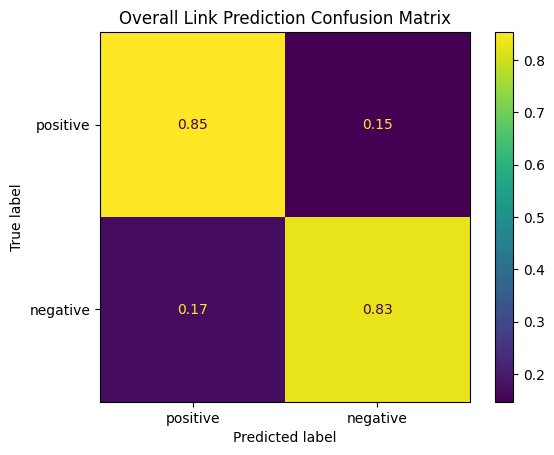

In [14]:
cm = confusion_matrix(all_preds, all_labels, normalize='true', labels=['positive', 'negative'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['positive', 'negative'])
disp.plot()
plt.title("Overall Link Prediction Confusion Matrix")

# Avaliação nas arestas mais recentes

In [15]:
print("Most Recent Link Prediction Report:")
print(classification_report(most_recent_labels, most_recent_preds))

Most Recent Link Prediction Report:
              precision    recall  f1-score   support

    negative       0.72      0.86      0.79      1808
    positive       0.83      0.66      0.74      1809

    accuracy                           0.76      3617
   macro avg       0.77      0.76      0.76      3617
weighted avg       0.77      0.76      0.76      3617



Text(0.5, 1.0, 'Most Recent Link Prediction Confusion Matrix')

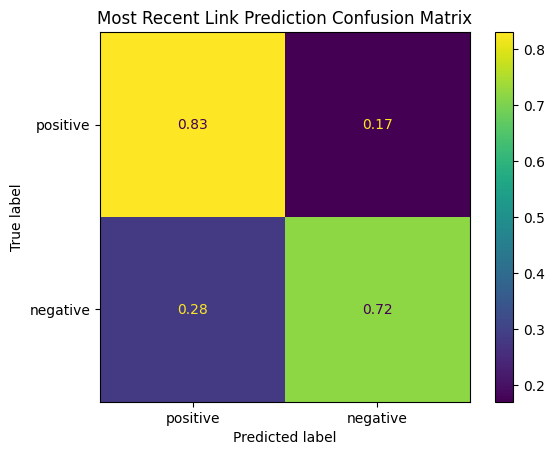

In [16]:
cm = confusion_matrix(most_recent_preds, most_recent_labels, normalize='true', labels=['positive', 'negative'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['positive', 'negative'])
disp.plot()
plt.title("Most Recent Link Prediction Confusion Matrix")

# Analisando predições 

Dois pontos de interesse -> padrões nos acertos e padrões nos erros.

- **Erros (difícil):**

In [17]:
import numpy as np

In [18]:
# filtrando erros do conjunto dificil
error_mask = np.array([pred["pred_label"] != pred["true_label"] for pred in hard_logs])
error_idxs = np.where(error_mask)[0]

In [19]:
# filtrando acertos do conjunto facil
correct_mask = np.array([pred["pred_label"] == pred["true_label"] for pred in easy_logs])
correct_idxs = np.where(correct_mask)[0]

In [20]:
# erros
for idx in np.random.choice(error_idxs, size=5, replace=False):
    u = hard_logs[idx]["u"]
    v = hard_logs[idx]["v"]
    print(f"Predicted: {hard_logs[idx]['pred_label']}, True: {hard_logs[idx]['true_label']}")
    print(f"Edge info:")
    for key, value in hard_info[idx].items():
        print(f"\t {key}: {value}")
    print(f"Event 1")
    for key, value in u.items():
        print(f"\t {key}: {value}")
    print(f"Event 2")
    for key, value in v.items():
        print(f"\t {key}: {value}")
    
    print(f"--"*10)
    

Predicted: negative, True: positive
Edge info:
	 label: positive
	 u: 6351_openai_chatgpt_desktop_2026-03-20
	 v: 6545_openai_chatbot_release_2026-03-26
	 weight: 0.4388452172279358
	 what_sim: 0.4388452172279358
	 where_sim: 1.0
	 when_sim: 0.42437284567695
Event 1
	 event_id: 6351_openai_chatgpt_desktop_2026-03-20
	 what: OpenAI is planning to release a desktop 'superapp' combining ChatGPT, Codex, and Atlas browser.
	 when: 2026-03-20-07:00:00
	 where: United States
	 who: OpenAI users, developers, and potentially competitors.
	 why: To streamline access to OpenAI's services and enhance user experience.
	 how: Through a downloadable desktop application integrating various OpenAI tools and a built-in browser.
Event 2
	 event_id: 6545_openai_chatbot_release_2026-03-26
	 what: OpenAI has postponed the release of an erotic chatbot.
	 when: 2026-03-26-07:00:00
	 where: United States
	 who: OpenAI
	 why: Concerns regarding ethical implications and potential misuse.
	 how: The decision was 

In [21]:
# acerto 
for idx in np.random.choice(correct_idxs, size=5, replace=False):
    u = easy_logs[idx]["u"]
    v = easy_logs[idx]["v"]
    print(f"Predicted: {easy_logs[idx]['pred_label']}, True: {easy_logs[idx]['true_label']}")
    print(f"Edge info:")
    for key, value in easy_info[idx].items():
        print(f"\t {key}: {value}")
    print(f"Event 1")
    for key, value in u.items():
        print(f"\t {key}: {value}")
    print(f"Event 2")
    for key, value in v.items():
        print(f"\t {key}: {value}")
    
    print(f"--"*10)
    

Predicted: positive, True: positive
Edge info:
	 label: positive
	 u: 284_ai_stocks_analysts_2026-03-05
	 v: 444_ai_stocks_analysts_2026-03-08
	 weight: 0.8742575645446777
	 what_sim: 0.8742575645446777
	 where_sim: 1.0
	 when_sim: 0.6514390575310556
Event 1
	 event_id: 284_ai_stocks_analysts_2026-03-05
	 what: Wall Street analysts recommend buying two artificial intelligence (AI) stocks with potential upside of 75% and 280%.
	 when: 2026-03-05-08:00:00
	 where: United States
	 who: Wall Street analysts, investors
	 why: Potential for significant financial gain from AI stock growth.
	 how: Analysts provide recommendations based on market research and financial modeling.
Event 2
	 event_id: 444_ai_stocks_analysts_2026-03-08
	 what: Wall Street analysts recommend selling two artificial intelligence (AI) stocks due to potential significant price drops.
	 when: 2026-03-08-08:00:00
	 where: United States
	 who: Wall Street Analysts, Investors
	 why: Potential for significant price drops in 

In [22]:
# erros do conjunto mais recente

# TODO: determinar os erros de outra forma. os arquivos de log nao batem.
error_mask = np.array([pred["pred_label"] != pred["true_label"] for pred in most_recent_logs])
error_idxs = np.where(error_mask)[0]    